In [2]:
# ================= 1. CONFIGURACIÓN DEL ENTORNO Y REPOSITORIO (ACE-FTS) =================
import os

print("Preparando el entorno computacional para ACE-FTS...")

# 1. Descargar el código fuente desde GitHub (usamos tu mismo repositorio principal)
!git clone https://github.com/JhonMurcia1502/Anexos-Tesis-Movea.git

# 2. Configurar el directorio de trabajo
BASE_DIR = '/content/Anexos-Tesis-Movea'
os.chdir(BASE_DIR) # Forzamos a Colab a trabajar dentro de esta carpeta

# 3. Descargar los datos masivos de ACE-FTS desde Zenodo
# (Reemplaza los textos entre comillas por los enlaces de descarga de Zenodo)
print("Descargando bases de datos de H2O y HDO desde Zenodo (esto puede tomar un momento)...")

!wget -O ACEFTS_L2_v5p2_H2O.nc "https://zenodo.org/records/21926241/files/ACEFTS_L2_v5p2_H2O.nc?download=1"
!wget -O ACEFTS_L2_v5p2_H2O_162.nc "https://zenodo.org/records/21926241/files/ACEFTS_L2_v5p2_H2O_162.nc?download=1"

print(f"✅ Entorno científico listo. Directorio de trabajo configurado en: {BASE_DIR}")
# ========================================================================================

Preparando el entorno computacional para ACE-FTS...
Cloning into 'Anexos-Tesis-Movea'...
remote: Enumerating objects: 32, done.
remote: Counting objects: 100% (32/32), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 32 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (32/32), 47.49 MiB | 15.36 MiB/s, done.
Resolving deltas: 100% (11/11), done.
Descargando bases de datos de H2O y HDO desde Zenodo (esto puede tomar un momento)...
--2026-08-14 23:56:34--  https://zenodo.org/records/21926241/files/ACEFTS_L2_v5p2_H2O.nc?download=1
Resolving zenodo.org (zenodo.org)... 188.184.98.114, 137.138.153.219, 188.185.43.153, ...
Connecting to zenodo.org (zenodo.org)|188.184.98.114|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 471106468 (449M) [application/octet-stream]
Saving to: ‘ACEFTS_L2_v5p2_H2O.nc’

ACEFTS_L2_v5p2_H2O. 100%[===================>] 449.28M  1012KB/s    in 6m 59s  

2026-08-15 00:03:34 (1.07 MB/s) - ‘ACEF

### Cálculo del Fraccionamiento Isotópico ($\delta D$)

Esta sección alinea temporalmente los perfiles de los instrumentos ACE-FTS para el vapor de agua ($H_2O$) y su isotopólogo pesado ($HDO$). El fraccionamiento isotópico se cuantifica utilizando la notación delta ($\delta D$), la cual expresa la desviación relativa de la razón isotópica de la muestra respecto al estándar oceánico (VSMOW):

$$ \delta D = \left( \frac{(HDO / H_2O)_{muestra}}{R_{VSMOW}} - 1 \right) \times 1000 $$

Donde $R_{VSMOW} = 3.1152 \times 10^{-4}$. Se aplica un filtro espacial para aislar la región tropical ($20^\circ S - 20^\circ N$) y se implementa  la mediana y percentiles 16-84% para mitigar el impacto de valores atípicos en la alta estratosfera.

Cargando datasets de ACE-FTS...
Sincronizando perfiles...
Calculando variables y fraccionamiento...
Calculando percentiles (16% - 84%)...


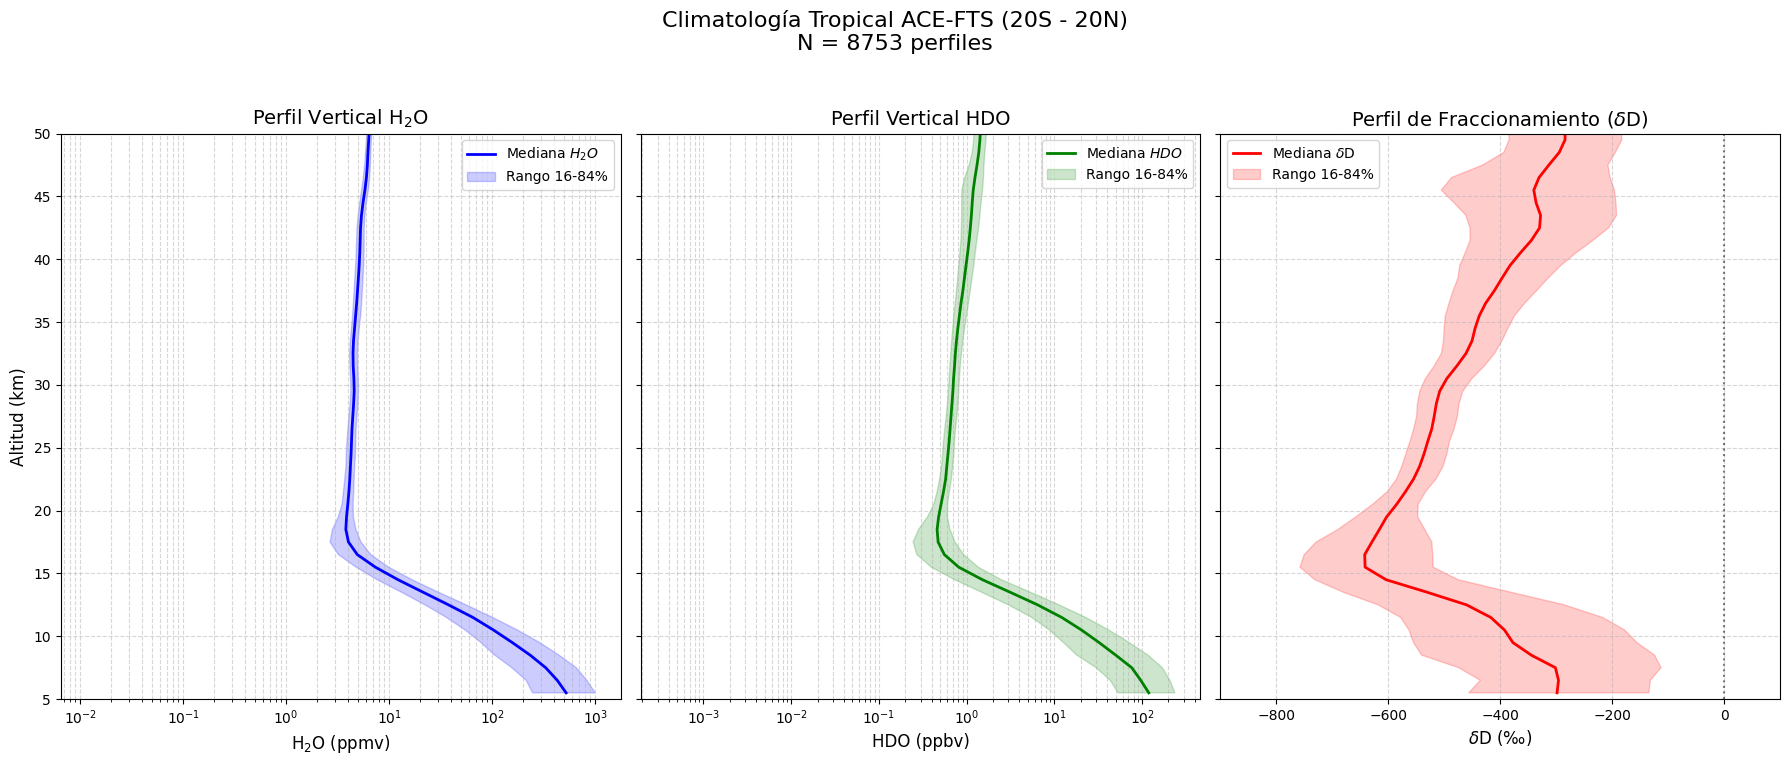

In [3]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

# --- 1. CARGA DE DATOS ---
# Las rutas apuntan al entorno local descargado de GitHub o Zenodo
BASE_DIR = '/content/Anexos-Tesis-Movea'
path_h2o = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O.nc')
path_hdo = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O_162.nc')

print("Cargando datasets de ACE-FTS...")
ds_h2o = xr.open_dataset(path_h2o)
ds_hdo = xr.open_dataset(path_hdo)

# --- 2. SINCRONIZACIÓN TEMPORAL ---
print("Sincronizando perfiles...")
timetags_h2o = ds_h2o['start_timetag'].values
timetags_hdo = ds_hdo['start_timetag'].values
common_timetags = np.intersect1d(timetags_h2o, timetags_hdo)

idx_h2o = np.where(np.isin(timetags_h2o, common_timetags))[0]
idx_hdo = np.where(np.isin(timetags_hdo, common_timetags))[0]

latitudes = ds_h2o['latitude'].values[idx_h2o]
altitudes = ds_h2o['altitude'].values

var_name_h2o = 'H2O_181' if 'H2O_181' in ds_h2o else 'H2O'
h2o_data = ds_h2o[var_name_h2o].values[idx_h2o, :]
hdo_data = ds_hdo['H2O_162'].values[idx_hdo, :]

# --- 3. FILTRO TROPICAL ---
mask_trop = (latitudes >= -20) & (latitudes <= 20)
h2o_trop = h2o_data[mask_trop, :]
hdo_trop = hdo_data[mask_trop, :]

# --- 4. CÁLCULOS FÍSICOS Y LIMPIEZA ---
print("Calculando variables y fraccionamiento...")
R_VSMOW = 3.1152e-4

h2o_clean = np.where(h2o_trop > 1e-8, h2o_trop, np.nan)
hdo_clean = np.where(hdo_trop > 1e-9, hdo_trop, np.nan)

with np.errstate(divide='ignore', invalid='ignore'):
    ratio = hdo_clean / h2o_clean
    delta_d = 1000 * (ratio - 1)

# Filtro físico de la tropopausa a la estratosfera
delta_d = np.where((delta_d > -900) & (delta_d < 100), delta_d, np.nan)

# --- 5. ESTADÍSTICA ROBUSTA ---
print("Calculando percentiles (16% - 84%)...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    # 1. H2O (ppmv)
    h2o_ppmv = h2o_clean * 1e6
    med_h2o = np.nanmedian(h2o_ppmv, axis=0)
    p16_h2o = np.nanpercentile(h2o_ppmv, 16, axis=0)
    p84_h2o = np.nanpercentile(h2o_ppmv, 84, axis=0)

    # 2. HDO (ppbv)
    hdo_ppbv = (hdo_clean * R_VSMOW) * 1e9
    med_hdo = np.nanmedian(hdo_ppbv, axis=0)
    p16_hdo = np.nanpercentile(hdo_ppbv, 16, axis=0)
    p84_hdo = np.nanpercentile(hdo_ppbv, 84, axis=0)

    # 3. Delta D
    med_delta = np.nanmedian(delta_d, axis=0)
    p16_delta = np.nanpercentile(delta_d, 16, axis=0)
    p84_delta = np.nanpercentile(delta_d, 84, axis=0)

# --- 6. RENDERIZADO GRÁFICO ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 8), sharey=True)

# Panel 1: H2O
ax1.plot(med_h2o, altitudes, 'b-', linewidth=2, label=r'Mediana $H_2O$')
valid_h2o = np.isfinite(med_h2o) & np.isfinite(p16_h2o) & np.isfinite(p84_h2o)
ax1.fill_betweenx(altitudes[valid_h2o], p16_h2o[valid_h2o], p84_h2o[valid_h2o], color='blue', alpha=0.2, label='Rango 16-84%')
ax1.set_xscale('log')
ax1.set_xlabel('H$_2$O (ppmv)', fontsize=12)
ax1.set_ylabel('Altitud (km)', fontsize=12)
ax1.set_title('Perfil Vertical H$_2$O', fontsize=14)
ax1.set_ylim(5, 50)
ax1.grid(True, which="both", ls="--", alpha=0.5)
ax1.legend()

# Panel 2: HDO
ax2.plot(med_hdo, altitudes, 'g-', linewidth=2, label=r'Mediana $HDO$')
valid_hdo = np.isfinite(med_hdo) & np.isfinite(p16_hdo) & np.isfinite(p84_hdo)
ax2.fill_betweenx(altitudes[valid_hdo], p16_hdo[valid_hdo], p84_hdo[valid_hdo], color='green', alpha=0.2, label='Rango 16-84%')
ax2.set_xscale('log')
ax2.set_xlabel('HDO (ppbv)', fontsize=12)
ax2.set_title('Perfil Vertical HDO', fontsize=14)
ax2.grid(True, which="both", ls="--", alpha=0.5)
ax2.legend()

# Panel 3: Delta D
ax3.plot(med_delta, altitudes, 'r-', linewidth=2, label=r'Mediana $\delta$D')
valid_delta = np.isfinite(med_delta) & np.isfinite(p16_delta) & np.isfinite(p84_delta)
ax3.fill_betweenx(altitudes[valid_delta], p16_delta[valid_delta], p84_delta[valid_delta], color='red', alpha=0.2, label='Rango 16-84%')
ax3.set_xlabel(r'$\delta$D (‰)', fontsize=12)
ax3.set_title(r'Perfil de Fraccionamiento ($\delta$D)', fontsize=14)
ax3.grid(True, which="both", ls="--", alpha=0.5)
ax3.axvline(0, color='k', ls=':', alpha=0.5)
ax3.set_xlim(-900, 100)
ax3.legend()

plt.suptitle(f'Climatología Tropical ACE-FTS (20S - 20N)\nN = {h2o_trop.shape[0]} perfiles', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Climatología Zonal Estacional (ACE-FTS)

Para visualizar la inyección de humedad y el fraccionamiento isotópico a nivel global, este algoritmo segmenta los datos espaciotemporales en ventanas estacionales (DJF, MAM, JJA, SON) y agrupa los perfiles en bines latitudinales de $5^\circ$. El resultado es un perfil 2D (Latitud vs. Altitud) que evidencia las plumas de hidratación de los sistemas convectivos y el enfriamiento diferencial de la tropopausa a través de la variable seleccionada.

Paso 1/7: Cargando y alineando archivos...
Paso 2/7: Filtrando valores de relleno...
Paso 3/7: Calculando variables isotópicas...
Paso 4/7: Unificando coordenada de tiempo...
Paso 5/7: Creando bins de latitud...
Paso 6/7: Procesando medias estacionales...
Paso 7/7: Reordenando tensores para renderizado...

¡Procesamiento completo! Generando visualización de 4 paneles...
✅ ¡Evidencia visual generada y guardada en: /content/Anexos-Tesis-Movea/Zonal_Climatology_H2O.png


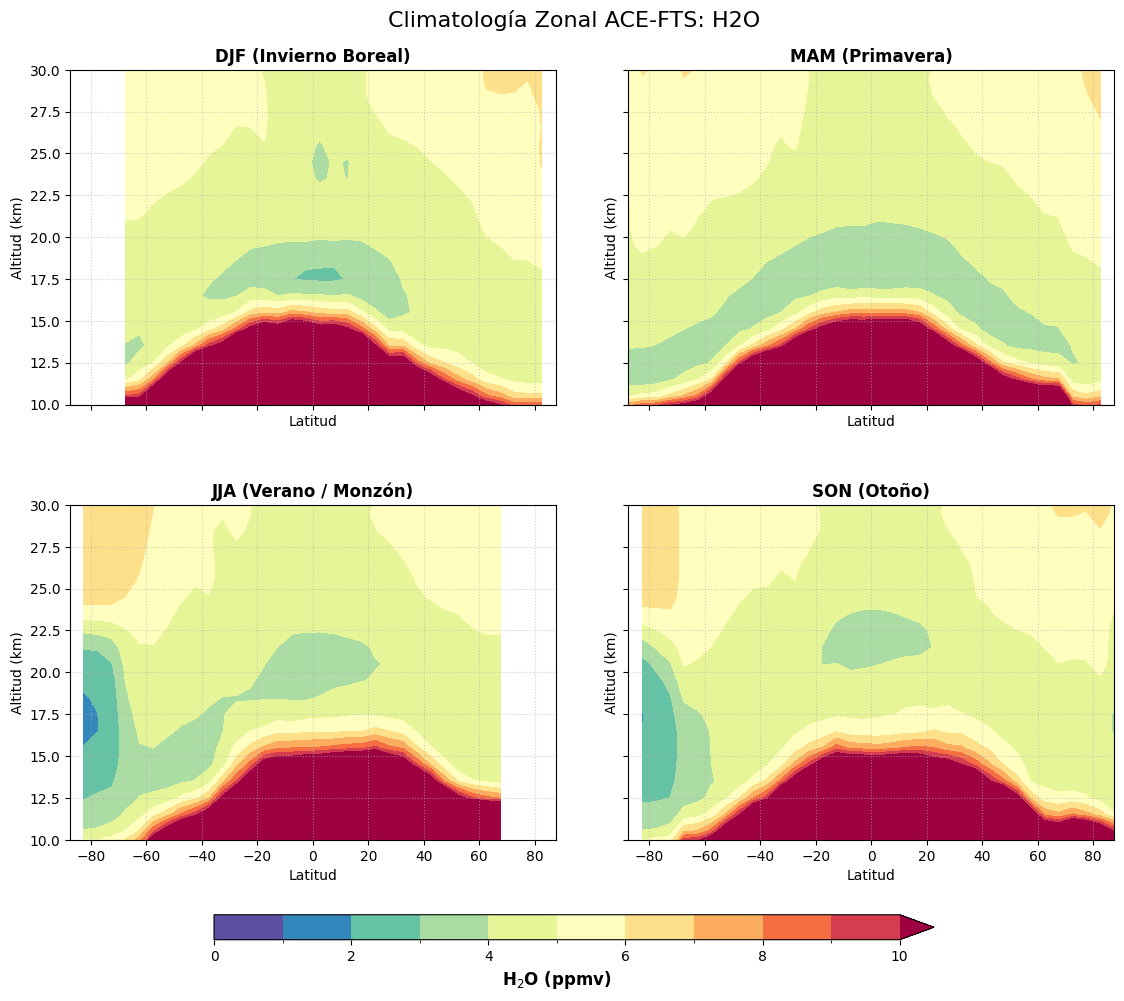

In [5]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import os

# --- 1. CONFIGURACIÓN DEL ENTORNO ---
# Apuntamos a los archivos descargados previamente desde Zenodo
BASE_DIR = '/content/Anexos-Tesis-Movea'
path_main_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O.nc')
path_subsidiary_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O_162.nc')

# Variable a graficar: Cambia esto según lo que desees visualizar
VARIABLE_A_GRAFICAR = 'H2O' # Opciones: 'delta_D', 'H2O', 'HDO', 'temperature'

# --- 2. Ocultar advertencias de cálculo ---
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

try:
    # --- 3. Cargar y Alinear Datos ---
    print("Paso 1/7: Cargando y alineando archivos...")
    ds_main = xr.open_dataset(path_main_iso)
    ds_iso = xr.open_dataset(path_subsidiary_iso)

    ds_main = ds_main.set_index(index=['orbit', 'sunset_sunrise']).rename({'index': 'profile'})
    ds_iso = ds_iso.set_index(index=['orbit', 'sunset_sunrise']).rename({'index': 'profile'})
    ds_main_aligned, ds_iso_aligned = xr.align(ds_main, ds_iso, join='inner')

    ds = xr.Dataset({
        'H2O': ds_main_aligned['H2O'],
        'H2O_162': ds_iso_aligned['H2O_162'],
        'temperature': ds_main_aligned['temperature'],
        'latitude': ds_main_aligned['latitude'],
        'year': ds_main_aligned['year'],
        'month': ds_main_aligned['month'],
        'day': ds_main_aligned['day'],
        'hour': ds_main_aligned['hour'],
    })

    # --- 4. Filtrar Valores Nulos ---
    print("Paso 2/7: Filtrando valores de relleno...")
    ds['H2O'] = ds['H2O'].where(ds['H2O'] > 0)
    ds['H2O_162'] = ds['H2O_162'].where(ds['H2O_162'] > 0)
    ds['temperature'] = ds['temperature'].where(ds['temperature'] > 0)

    # --- 5. Calcular Fraccionamiento Isotópico ---
    print(f"Paso 3/7: Calculando variables isotópicas...")
    R_VSMOW = 3.1152e-4
    ds['delta_D'] = 1000 * ((ds['H2O_162'] / ds['H2O']) - 1)
    ds['HDO'] = (ds['H2O_162'] * R_VSMOW) * 1e9 # ppbv
    ds['H2O'] = ds['H2O'] * 1e6 # ppmv

    # --- 6. Coordenada Temporal Estándar ---
    print("Paso 4/7: Unificando coordenada de tiempo...")
    time_df = pd.DataFrame({
        'year': ds['year'].values, 'month': ds['month'].values,
        'day': ds['day'].values, 'hour': ds['hour'].values
    })
    datetime_series = pd.to_datetime(time_df)
    ds = ds.assign_coords(time=('profile', datetime_series.values))
    ds = ds.drop_vars(['year', 'month', 'day', 'hour'])

    # --- 7. Grillado Latitudinal ---
    print("Paso 5/7: Creando bins de latitud...")
    lat_bins = np.arange(-90, 95, 5)
    lat_labels = np.arange(-87.5, 92.5, 5)
    ds['lat_bin'] = xr.DataArray(
        pd.cut(ds.latitude, bins=lat_bins, labels=lat_labels),
        dims='profile'
    )
    ds = ds.drop_vars(['latitude'])

    # --- 8. Agrupación Climatológica ---
    print("Paso 6/7: Procesando medias estacionales...")
    climatology = ds.groupby(['time.season', 'lat_bin']).mean(dim='profile')

    print("Paso 7/7: Reordenando tensores para renderizado...")
    climatology = climatology.unstack()
    climatology = climatology.rename({'lat_bin': 'latitude'})
    climatology = climatology.reindex(season=['DJF', 'MAM', 'JJA', 'SON'])

    # --- 9. Renderizado Gráfico Integrado ---
    print("\n¡Procesamiento completo! Generando visualización de 4 paneles...")

    data_to_plot = climatology[VARIABLE_A_GRAFICAR]

    # Parametrización dinámica según la variable
    if VARIABLE_A_GRAFICAR == 'delta_D':
        levels = np.linspace(-900, -300, 13)
        cbar_label = r'$\delta$D (‰ - permil)'
        cmap = 'viridis'
    elif VARIABLE_A_GRAFICAR == 'H2O':
        levels = np.linspace(0, 10, 11)
        cbar_label = 'H$_2$O (ppmv)'
        cmap = 'Spectral_r'
    elif VARIABLE_A_GRAFICAR == 'HDO':
        levels = np.linspace(0, 2.5, 11)
        cbar_label = 'HDO (ppbv)'
        cmap = 'cividis'
    else:
        levels = np.linspace(190, 250, 13)
        cbar_label = 'Temperatura (K)'
        cmap = 'coolwarm'

    # Renderizado con Xarray
    g = data_to_plot.plot.contourf(
        x='latitude', y='altitude',
        col='season', col_wrap=2,
        figsize=(12, 10),
        levels=levels,
        cmap=cmap,
        add_colorbar=False
    )

    fig = g.fig
    fig.subplots_adjust(top=0.92, bottom=0.15, left=0.08, right=0.95, hspace=0.3, wspace=0.15)

    season_map = {
        'DJF': 'DJF (Invierno Boreal)', 'MAM': 'MAM (Primavera)',
        'JJA': 'JJA (Verano / Monzón)', 'SON': 'SON (Otoño)'
    }

    # Configuración de los 4 paneles
    for ax in g.axes.flat:
        current_title = ax.get_title()
        if current_title:
            season_key = current_title.split(' = ')[-1]
            if season_key in season_map:
                ax.set_title(season_map[season_key], fontsize=12, fontweight='bold')

        # Enfoque en la tropopausa y alta estratosfera
        ax.set_ylim(10, 30)
        ax.set_xlabel('Latitud')
        ax.set_ylabel('Altitud (km)')
        ax.grid(True, linestyle=':', alpha=0.6)

    plt.suptitle(f'Climatología Zonal ACE-FTS: {VARIABLE_A_GRAFICAR}', fontsize=16, y=0.98)

    # Barra de color horizontal unificada
    cbar_ax = fig.add_axes([0.2, 0.05, 0.6, 0.025])
    mappable = g.axes.flat[0].collections[0]
    cb = fig.colorbar(mappable, cax=cbar_ax, orientation='horizontal')
    cb.set_label(cbar_label, fontsize=12, fontweight='bold')
    cb.ax.tick_params(labelsize=10)

    # Exportación
    output_filename = os.path.join(BASE_DIR, f'Zonal_Climatology_{VARIABLE_A_GRAFICAR}.png')
    plt.savefig(output_filename, dpi=150)

    print(f"✅ ¡Evidencia visual generada y guardada en: {output_filename}")
    plt.show()

except Exception as e:
    print(f"❌ Ocurrió un error en la ejecución: {e}")

### Distribución Espacial (Mapas Climatológicos Estacionales)

Para mapear la inyección de humedad en la alta tropopausa/baja estratosfera, los perfiles satelitales se evalúan en un nivel isohípsico específico. El campo termodinámico e isotópico es posteriormente agrupado (binning) en una malla global de $5^\circ \times 10^\circ$ (latitud/longitud) para observar las anomalías espaciales asociadas a la convección profunda de los grandes sistemas monzónicos.

In [9]:
!pip install cartopy
from scipy.ndimage import gaussian_filter

Paso 1/9: Cargando archivos para mapa global (JJA)...
Paso 2/9: Filtrando valores de relleno...
Paso 3/9: Calculando variables isotópicas...
Paso 4/9: Unificando coordenada de tiempo...
Paso 5/9: Seleccionando altitud más cercana a 17.0 km...
Paso 6/9: Creando malla espacial...
Paso 7/9: Agrupando tensores espacialmente...
Paso 8/9: Reordenando datos para el gráfico...
Paso 9/9: ¡Generando mapa topológico para JJA!
✅ ¡Evidencia cartográfica guardada en: /content/Anexos-Tesis-Movea/ACE_FTS_Global_delta_D_17km_JJA.png


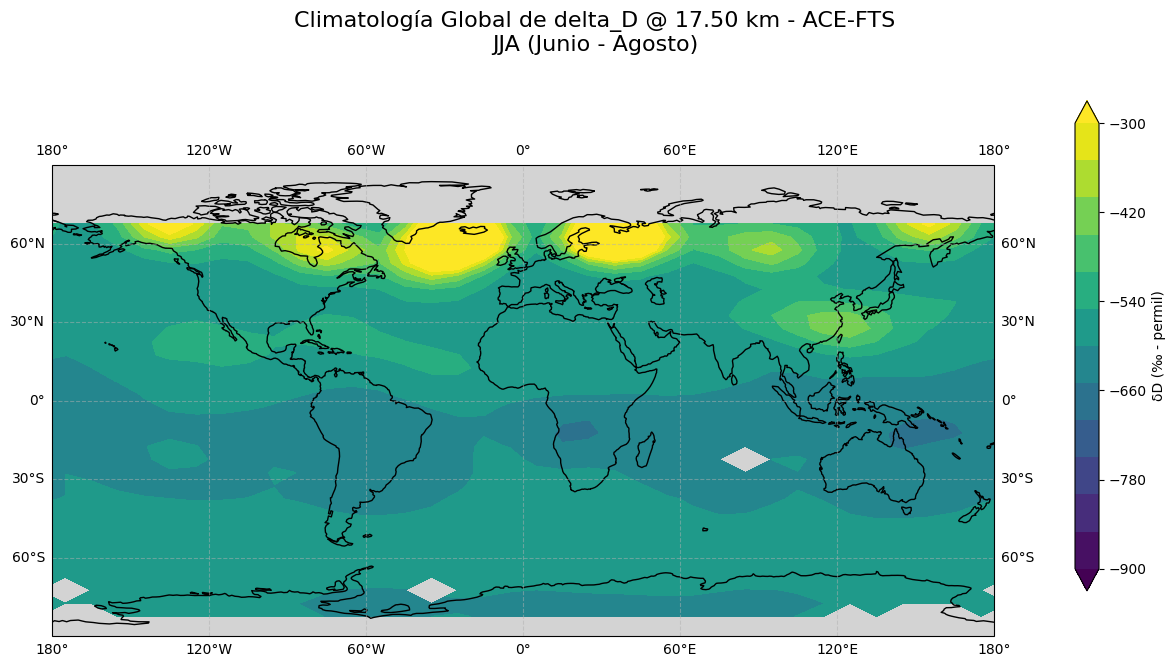

In [11]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import os
from scipy.ndimage import gaussian_filter  # <--- NUEVA IMPORTACIÓN PARA EL FILTRO

# --- IMPORTANTE: Se requiere Cartopy para este script ---
try:
    import cartopy.crs as ccrs
    from cartopy.util import add_cyclic_point
except ImportError:
    print("¡Advertencia! No se encontró 'cartopy'.")
    print("El gráfico fallará. Instálalo ejecutando la siguiente celda: !pip install cartopy")
# --------------------------------------------------------

# --- 1. CONFIGURACIÓN DEL ENTORNO ---
# Apuntamos a los archivos descargados desde Zenodo
BASE_DIR = '/content/Anexos-Tesis-Movea'
path_main_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O.nc')
path_subsidiary_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O_162.nc')

# Variable a graficar: Cambia esto según lo que desees visualizar
VARIABLE_A_GRAFICAR = 'delta_D' # Opciones: 'delta_D', 'H2O', 'HDO', 'temperature'

# Altitud de interés (Típicamente 16-18 km para estudiar la tropopausa)
ALTITUD_SELECCIONADA = 17.0

# Elige la estación que quieres graficar
SEASON_TO_PLOT = 'JJA' # Opciones: 'DJF', 'MAM', 'JJA', 'SON'

# --- 2. Ocultar advertencias de cálculo ---
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

try:
    # --- 3. Cargar y Alinear Datos ---
    print(f"Paso 1/9: Cargando archivos para mapa global ({SEASON_TO_PLOT})...")
    ds_main = xr.open_dataset(path_main_iso)
    ds_iso = xr.open_dataset(path_subsidiary_iso)

    ds_main = ds_main.set_index(index=['orbit', 'sunset_sunrise']).rename({'index': 'profile'})
    ds_iso = ds_iso.set_index(index=['orbit', 'sunset_sunrise']).rename({'index': 'profile'})
    ds_main_aligned, ds_iso_aligned = xr.align(ds_main, ds_iso, join='inner')

    ds = xr.Dataset({
        'H2O': ds_main_aligned['H2O'],
        'H2O_162': ds_iso_aligned['H2O_162'],
        'temperature': ds_main_aligned['temperature'],
        'latitude': ds_main_aligned['latitude'],
        'longitude': ds_main_aligned['longitude'],
        'year': ds_main_aligned['year'],
        'month': ds_main_aligned['month'],
        'day': ds_main_aligned['day'],
        'hour': ds_main_aligned['hour'],
    })

    # --- 4. Filtrar Valores Nulos ---
    print("Paso 2/9: Filtrando valores de relleno...")
    ds['H2O'] = ds['H2O'].where(ds['H2O'] > 0)
    ds['H2O_162'] = ds['H2O_162'].where(ds['H2O_162'] > 0)
    ds['temperature'] = ds['temperature'].where(ds['temperature'] > 0)

    # --- 5. Calcular Fraccionamiento Isotópico ---
    print("Paso 3/9: Calculando variables isotópicas...")
    R_VSMOW = 3.1152e-4
    ds['delta_D'] = 1000 * ((ds['H2O_162'] / ds['H2O']) - 1)
    ds['HDO'] = (ds['H2O_162'] * R_VSMOW) * 1e9 # ppbv
    ds['H2O'] = ds['H2O'] * 1e6 # ppmv

    # --- 6. Coordenada Temporal Estándar ---
    print("Paso 4/9: Unificando coordenada de tiempo...")
    time_df = pd.DataFrame({
        'year': ds['year'].values, 'month': ds['month'].values,
        'day': ds['day'].values, 'hour': ds['hour'].values
    })
    datetime_series = pd.to_datetime(time_df)
    ds = ds.assign_coords(time=('profile', datetime_series.values))
    ds = ds.drop_vars(['year', 'month', 'day', 'hour'])

    # --- 7. Extracción Isohípsica ---
    print(f"Paso 5/9: Seleccionando altitud más cercana a {ALTITUD_SELECCIONADA} km...")
    ds_at_alt = ds.sel(altitude=ALTITUD_SELECCIONADA, method='nearest')
    actual_alt = ds_at_alt.altitude.values

    # --- 8. Grillado Global ---
    print("Paso 6/9: Creando malla espacial...")
    lat_bins = np.arange(-90, 95, 5)
    lat_labels = np.arange(-87.5, 92.5, 5)
    lon_bins = np.arange(-180, 190, 10)
    lon_labels = np.arange(-175, 185, 10)

    ds_at_alt['lat_bin'] = xr.DataArray(
        pd.cut(ds_at_alt.latitude, bins=lat_bins, labels=lat_labels), dims='profile'
    )
    ds_at_alt['lon_bin'] = xr.DataArray(
        pd.cut(ds_at_alt.longitude, bins=lon_bins, labels=lon_labels), dims='profile'
    )
    ds_at_alt = ds_at_alt.drop_vars(['latitude', 'longitude'])

    # --- 9. Agrupación Climatológica ---
    print("Paso 7/9: Agrupando tensores espacialmente...")
    climatology = ds_at_alt.groupby(['time.season', 'lat_bin', 'lon_bin']).mean(dim='profile')

    print("Paso 8/9: Reordenando datos para el gráfico...")
    climatology = climatology.unstack()
    climatology = climatology.rename({'lat_bin': 'latitude', 'lon_bin': 'longitude'})
    climatology = climatology.reindex(season=['DJF', 'MAM', 'JJA', 'SON'])

    # --- 10. Renderizado Cartográfico ---
    print(f"Paso 9/9: ¡Generando mapa topológico para {SEASON_TO_PLOT}!")
    data_to_plot = climatology[VARIABLE_A_GRAFICAR]

    if VARIABLE_A_GRAFICAR == 'delta_D':
        levels = np.linspace(-900, -300, 13)
        cbar_label = 'δD (‰ - permil)'
        cmap = 'viridis'
    elif VARIABLE_A_GRAFICAR == 'H2O':
        levels = np.linspace(0, 10, 11)
        cbar_label = 'H₂O (ppmv)'
        cmap = 'Spectral_r'
    elif VARIABLE_A_GRAFICAR == 'HDO':
        levels = np.linspace(0, 2.5, 11)
        cbar_label = 'HDO (ppbv)'
        cmap = 'cividis'
    else:
        levels = np.linspace(190, 250, 13)
        cbar_label = 'Temperatura (K)'
        cmap = 'coolwarm'

    fig, ax = plt.subplots(
        nrows=1, ncols=1, figsize=(12, 7),
        subplot_kw={'projection': ccrs.PlateCarree()}
    )

    season_map = {
        'DJF': 'DJF (Diciembre - Febrero)', 'MAM': 'MAM (Marzo - Mayo)',
        'JJA': 'JJA (Junio - Agosto)', 'SON': 'SON (Septiembre - Noviembre)'
    }

    data_season = data_to_plot.sel(season=SEASON_TO_PLOT)
    data_np = data_season.values
    lons_np = data_season.longitude.values
    data_cyclic, lons_cyclic = add_cyclic_point(data_np, coord=lons_np)

    # 1. Rellenar temporalmente los NaNs (blancos) con la media para que el filtro no falle
    data_filled = np.nan_to_num(data_cyclic, nan=np.nanmean(data_cyclic))

    # 2. Aplicar un filtro gaussiano suave (sigma controla qué tan borroso/suave se vuelve)
    # Puedes ajustar sigma=1.2 si lo quieres más o menos difuminado.
    data_smoothed = gaussian_filter(data_filled, sigma=1.2)

    # 3. Volver a poner los NaNs originales para no "inventar" datos donde no hay
    data_smoothed[np.isnan(data_cyclic)] = np.nan

    # 4. Graficar EXCLUSIVAMENTE los datos suavizados
    im = ax.contourf(
        lons_cyclic, data_season.latitude, data_smoothed,
        levels=levels, cmap=cmap, transform=ccrs.PlateCarree(), extend='both'
    )

    ax.set_facecolor('lightgray') # Fondo gris para diferenciar zonas sin datos

    ax.coastlines()
    ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    ax.set_extent([-180, 180, -90, 90])

    titulo_grafico = (
        f'Climatología Global de {VARIABLE_A_GRAFICAR} @ {actual_alt:.2f} km - ACE-FTS\n'
        f'{season_map[SEASON_TO_PLOT]}'
    )
    plt.suptitle(titulo_grafico, fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 0.88, 0.90])

    cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical', label=cbar_label, extend='both')
    cbar.set_ticks(np.linspace(levels.min(), levels.max(), 6))

    output_filename = os.path.join(BASE_DIR, f'ACE_FTS_Global_{VARIABLE_A_GRAFICAR}_{ALTITUD_SELECCIONADA:.0f}km_{SEASON_TO_PLOT}.png')
    plt.savefig(output_filename, dpi=150)

    print(f"✅ ¡Evidencia cartográfica guardada en: {output_filename}")
    plt.show()

except Exception as e:
    print(f"❌ Ocurrió un error en la ejecución: {e}")

### Evolución Espaciotemporal Global (Ciclo Estacional Completo)

Este módulo extiende el análisis cartográfico para evaluar la variabilidad intraanual del campo isotópico y termodinámico en un nivel isohípsico de interés (ej. la alta tropopausa tropical, ~17 km). El algoritmo procesa la totalidad de la base de datos de ACE-FTS para generar un panel comparativo simultáneo de las cuatro estaciones meteorológicas estándar (DJF, MAM, JJA, SON), permitiendo observar la migración espacio-temporal de la hidratación estratosférica.

**Tratamiento Metodológico:**
* **Control de Calidad:** Antes del cálculo del fraccionamiento isotópico ($\delta D$), se implementa una función de enmascaramiento que cruza las mediciones crudas con las matrices de error instrumental nativas de la misión. Esto garantiza la exclusión de perfiles anómalos, mediciones negativas no físicas o datos con un ruido espectral inaceptable.
* **Filtro Espacial Gaussiano:** Tras realizar el agrupamiento climatológico global en celdas de $5^\circ \times 10^\circ$ (latitud/longitud), se aplica un filtro de suavizado espacial Gaussiano ($\sigma = 1.2$) sobre el tensor de datos. Este procedimiento mitiga los artefactos visuales derivados de la discretización de la malla y permite trazar las plumas continuas de inyección convectiva asociadas a los grandes sistemas monzónicos.

Paso 1/7: Cargando y alineando datos...
Paso 2/7: Aplicando filtro riguroso de calidad instrumental...
Paso 3/7: Calculando fraccionamiento y concentraciones...
Paso 4/7: Unificando coordenada temporal...
Paso 5/7: Seleccionando nivel isohípsico (~17.0 km)...
Paso 6/7: Agrupando en climatología estacional global...
Paso 7/7: Generando panel 2x2 suavizado (Filtro Gaussiano)...
✅ ¡Panel 2x2 guardado exitosamente en: /content/Anexos-Tesis-Movea/ACE_FTS_Global_4Paneles_H2O_17km_suavizado.png


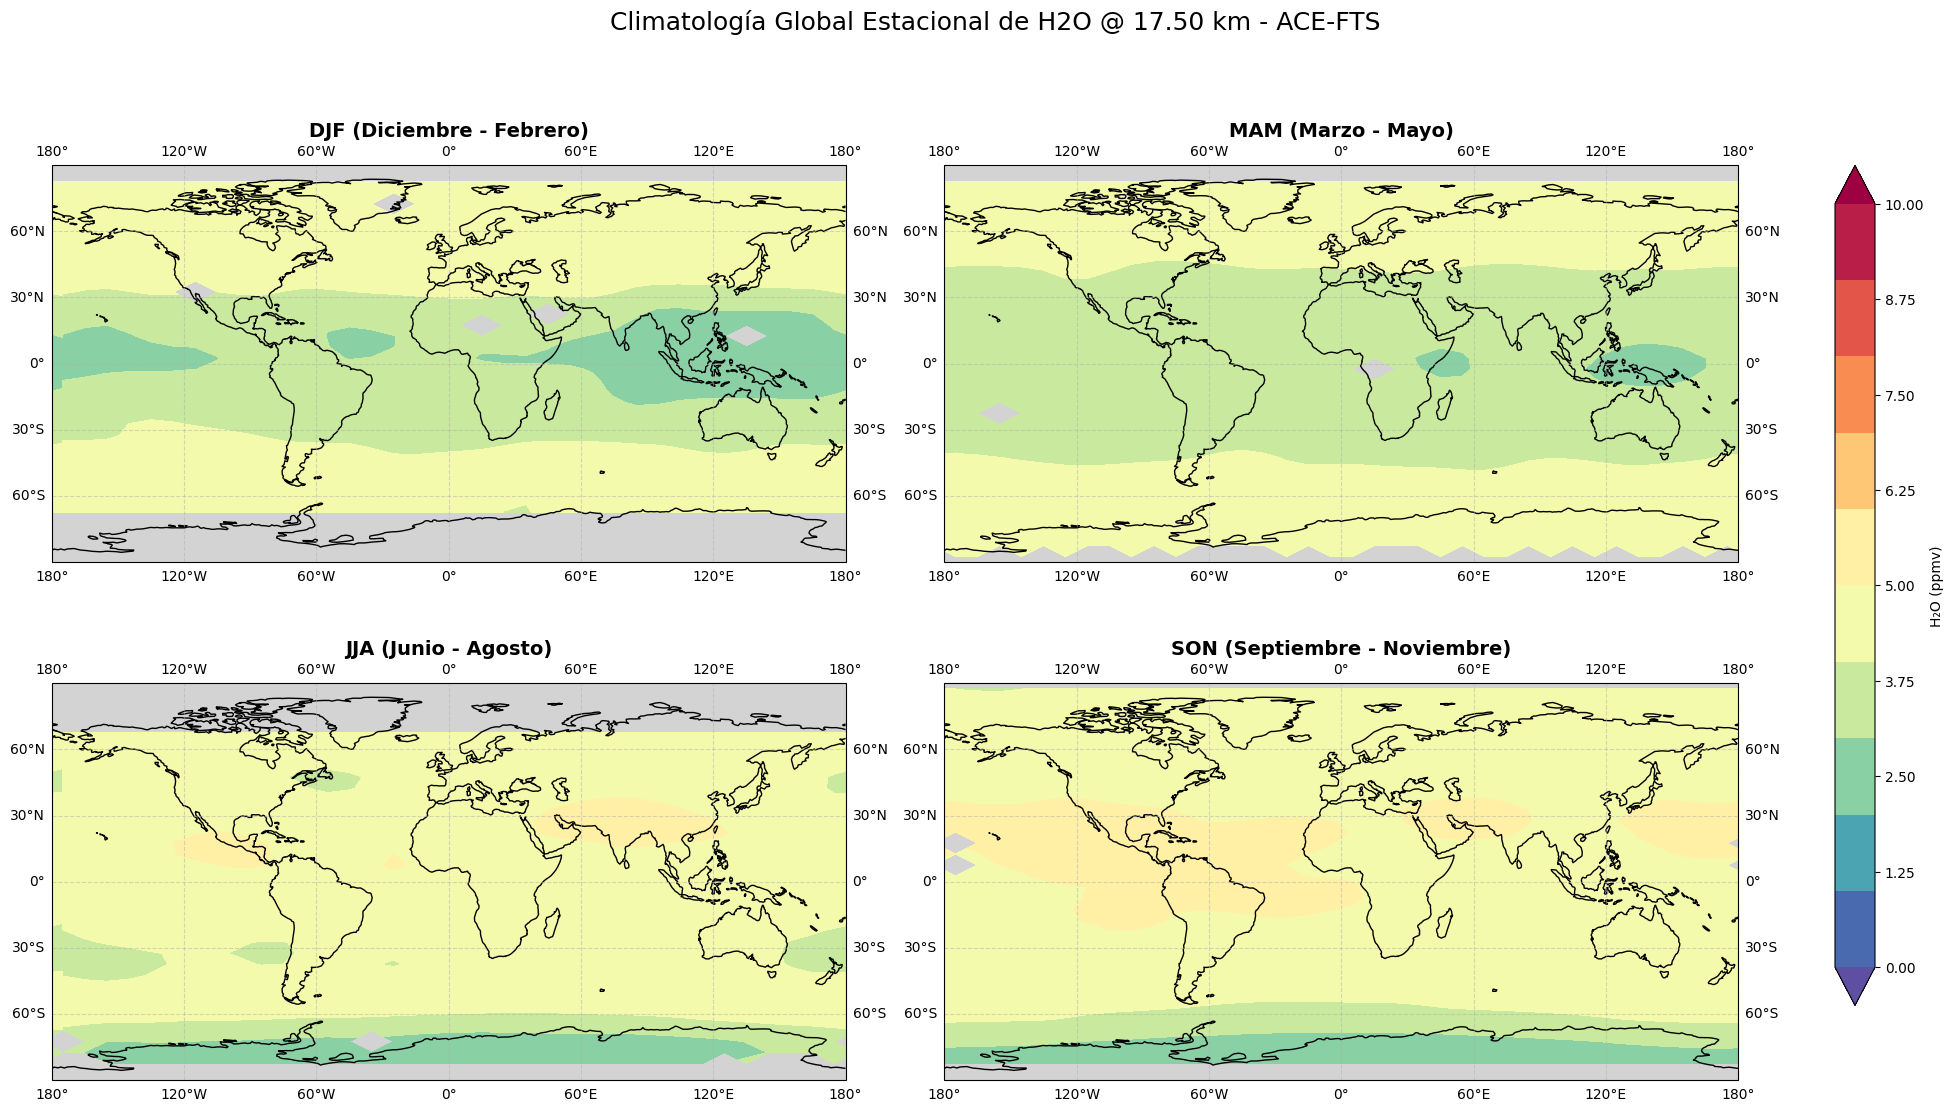

In [13]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import os
from scipy.ndimage import gaussian_filter

# --- IMPORTANTE: Se requiere Cartopy para este script ---
try:
    import cartopy.crs as ccrs
    from cartopy.util import add_cyclic_point
except ImportError:
    print("¡Advertencia! No se encontró 'cartopy'.")
    print("El gráfico fallará. Instálalo ejecutando: !pip install cartopy")
# --------------------------------------------------------

# --- 1. CONFIGURACIÓN DEL ENTORNO ---
BASE_DIR = '/content/Anexos-Tesis-Movea'
path_main_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O.nc')
path_subsidiary_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O_162.nc')

# Elige la variable a graficar en los 4 paneles
VARIABLE_A_GRAFICAR = 'H2O' # Opciones: 'delta_D', 'H2O', 'HDO', 'temperature'
ALTITUD_SELECCIONADA = 17.0

warnings.filterwarnings('ignore')

# --- FUNCIÓN DE FILTRADO FÍSICO (Calidad Instrumental) ---
def aplicar_filtro_readme(data, error):
    mask_fill = data != -999
    mask_flag = error != -888
    is_negative = data < 0
    is_very_negative = is_negative & (np.abs(data) > 2 * error)
    mask_valid_negatives = ~is_very_negative
    return data.where(mask_fill & mask_flag & mask_valid_negatives)

try:
    # 1. Cargar
    print("Paso 1/7: Cargando y alineando datos...")
    ds_main = xr.open_dataset(path_main_iso)
    ds_iso = xr.open_dataset(path_subsidiary_iso)
    ds_main = ds_main.set_index(index=['orbit', 'sunset_sunrise']).rename({'index': 'profile'})
    ds_iso = ds_iso.set_index(index=['orbit', 'sunset_sunrise']).rename({'index': 'profile'})
    ds_main_aligned, ds_iso_aligned = xr.align(ds_main, ds_iso, join='inner')

    ds = xr.Dataset({
        'H2O': ds_main_aligned['H2O'], 'H2O_error': ds_main_aligned['H2O_error'],
        'H2O_162': ds_iso_aligned['H2O_162'], 'H2O_162_error': ds_iso_aligned['H2O_162_error'],
        'temperature': ds_main_aligned['temperature'], 'latitude': ds_main_aligned['latitude'],
        'longitude': ds_main_aligned['longitude'], 'year': ds_main_aligned['year'],
        'month': ds_main_aligned['month'], 'day': ds_main_aligned['day'], 'hour': ds_main_aligned['hour'],
    })

    # 2. Filtrar
    print("Paso 2/7: Aplicando filtro riguroso de calidad instrumental...")
    ds['H2O'] = aplicar_filtro_readme(ds['H2O'], ds['H2O_error'])
    ds['H2O_162'] = aplicar_filtro_readme(ds['H2O_162'], ds['H2O_162_error'])
    ds['temperature'] = ds['temperature'].where(ds['temperature'] > 0)

    # 3. Calcular
    print("Paso 3/7: Calculando fraccionamiento y concentraciones...")
    R_VSMOW = 3.1152e-4
    ds['delta_D'] = 1000 * ((ds['H2O_162'] / ds['H2O']) - 1)
    ds['delta_D'] = ds['delta_D'].where((ds['delta_D'] > -1000) & (ds['delta_D'] < 500))
    ds['HDO'] = (ds['H2O_162'] * R_VSMOW) * 1e9
    ds['H2O'] = ds['H2O'] * 1e6

    # 4. Tiempo
    print("Paso 4/7: Unificando coordenada temporal...")
    year = ds['year'].astype(int); month = ds['month'].astype(int)
    day = ds['day'].astype(int); hour = ds['hour'].astype(int)
    time_df = pd.DataFrame({'year': year.values, 'month': month.values, 'day': day.values, 'hour': hour.values})
    ds = ds.assign_coords(time=('profile', pd.to_datetime(time_df).values))
    ds = ds.drop_vars(['year', 'month', 'day', 'hour', 'H2O_error', 'H2O_162_error'])

    # 5. Seleccionar Altitud y Bins
    print(f"Paso 5/7: Seleccionando nivel isohípsico (~{ALTITUD_SELECCIONADA} km)...")
    ds_at_alt = ds.sel(altitude=ALTITUD_SELECCIONADA, method='nearest')
    actual_alt = ds_at_alt.altitude.values # Capturamos la altitud real

    lat_bins = np.arange(-90, 95, 5); lat_labels = np.arange(-87.5, 92.5, 5)
    lon_bins = np.arange(-180, 190, 10); lon_labels = np.arange(-175, 185, 10)

    ds_at_alt['lat_bin'] = xr.DataArray(pd.cut(ds_at_alt.latitude, bins=lat_bins, labels=lat_labels), dims='profile')
    ds_at_alt['lon_bin'] = xr.DataArray(pd.cut(ds_at_alt.longitude, bins=lon_bins, labels=lon_labels), dims='profile')
    ds_at_alt = ds_at_alt.drop_vars(['latitude', 'longitude'])

    # 6. Agrupar
    print("Paso 6/7: Agrupando en climatología estacional global...")
    climatology = ds_at_alt.groupby(['time.season', 'lat_bin', 'lon_bin']).mean(dim='profile')
    climatology = climatology.unstack().rename({'lat_bin': 'latitude', 'lon_bin': 'longitude'})
    climatology = climatology.reindex(season=['DJF', 'MAM', 'JJA', 'SON'])

    # 7. Graficar con Cartopy
    print("Paso 7/7: Generando panel 2x2 suavizado (Filtro Gaussiano)...")
    data_to_plot = climatology[VARIABLE_A_GRAFICAR]

    if VARIABLE_A_GRAFICAR == 'delta_D':
        levels = np.linspace(-900, -300, 13)
        cbar_label = 'δD (‰ - permil)'
        cmap = 'viridis'
    elif VARIABLE_A_GRAFICAR == 'H2O':
        levels = np.linspace(0, 10, 11)
        cbar_label = 'H₂O (ppmv)'
        cmap = 'Spectral_r'
    elif VARIABLE_A_GRAFICAR == 'HDO':
        levels = np.linspace(0, 2.5, 11)
        cbar_label = 'HDO (ppbv)'
        cmap = 'cividis'
    else:
        levels = np.linspace(190, 250, 13)
        cbar_label = 'Temperatura (K)'
        cmap = 'coolwarm'

    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 12), subplot_kw={'projection': ccrs.PlateCarree()})

    season_map = {
        'DJF': 'DJF (Diciembre - Febrero)', 'MAM': 'MAM (Marzo - Mayo)',
        'JJA': 'JJA (Junio - Agosto)', 'SON': 'SON (Septiembre - Noviembre)'
    }

    im = None
    for ax, season in zip(axes.flat, ['DJF', 'MAM', 'JJA', 'SON']):
        data_season = data_to_plot.sel(season=season)

        data_np = data_season.values
        lons_np = data_season.longitude.values
        data_cyclic, lons_cyclic = add_cyclic_point(data_np, coord=lons_np)

        # --- APLICACIÓN DEL FILTRO GAUSSIANO EN CADA PANEL ---
        data_filled = np.nan_to_num(data_cyclic, nan=np.nanmean(data_cyclic))
        data_smoothed = gaussian_filter(data_filled, sigma=1.2)
        data_smoothed[np.isnan(data_cyclic)] = np.nan
        # -----------------------------------------------------

        im = ax.contourf(
            lons_cyclic, data_season.latitude, data_smoothed,
            levels=levels, cmap=cmap, transform=ccrs.PlateCarree(), extend='both'
        )

        ax.set_facecolor('lightgray') # Fondo gris para áreas sin cobertura satelital
        ax.coastlines()
        ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
        ax.set_title(season_map[season], fontsize=14, fontweight='bold')
        ax.set_extent([-180, 180, -90, 90])

    plt.suptitle(f'Climatología Global Estacional de {VARIABLE_A_GRAFICAR} @ {actual_alt:.2f} km - ACE-FTS', fontsize=18, y=0.98)

    # Ajustar espacios para que no se sobrepongan los paneles
    plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])

    # Barra de color única para los 4 mapas
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical', label=cbar_label, extend='both')
    cbar.set_ticks(np.linspace(levels.min(), levels.max(), 9))

    # Guardado automático
    output_filename = os.path.join(BASE_DIR, f'ACE_FTS_Global_4Paneles_{VARIABLE_A_GRAFICAR}_{ALTITUD_SELECCIONADA:.0f}km_suavizado.png')
    plt.savefig(output_filename, dpi=150)

    print(f"✅ ¡Panel 2x2 guardado exitosamente en: {output_filename}")
    plt.show()

except Exception as e:
    print(f"❌ Error en la ejecución: {e}")

### Visualización Cinemática: Ciclo Anual Mensualizado (.GIF)

Para analizar la evolución continua de la tropopausa y la estratosfera a lo largo del año, este módulo desagrega la climatología en una resolución mensual ($12$ fotogramas, de enero a diciembre).

El algoritmo procesa la malla espacial para cada mes, aplica el suavizado espacial Gaussiano ($\sigma = 1.2$) para mantener consistencia visual entre cuadros, y ensambla dinámicamente un archivo `.gif` animado a una velocidad de $2 \text{ fps}$ ($500 \text{ ms}$ por fotograma). Esta herramienta permite apreciar la transición temporal de las plumas convectivas y la oscilación estacional de la temperatura e isotopólogos.

In [14]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import os
import imageio
from scipy.ndimage import gaussian_filter

# --- IMPORTANTE: Se requiere Cartopy para este script ---
try:
    import cartopy.crs as ccrs
    from cartopy.util import add_cyclic_point
except ImportError:
    print("¡Advertencia! No se encontró 'cartopy'.")
    print("El gráfico fallará. Instálalo ejecutando: !pip install cartopy")
# --------------------------------------------------------

# --- 1. CONFIGURACIÓN DEL ENTORNO ---
BASE_DIR = '/content/Anexos-Tesis-Movea'
path_main_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O.nc')
path_subsidiary_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O_162.nc')

# Variable a animar
VARIABLE_A_GRAFICAR = 'HDO' # Opciones: 'delta_D', 'H2O', 'HDO', 'temperature'
ALTITUD_SELECCIONADA = 17.0

# Carpeta temporal para los cuadros del GIF
frames_dir = os.path.join(BASE_DIR, 'gif_frames_ace')
os.makedirs(frames_dir, exist_ok=True)
filenames = []

warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

try:
    # --- 2. Cargar y Alinear Datos ---
    print("Paso 1/6: Cargando archivos de ACE-FTS...")
    ds_main = xr.open_dataset(path_main_iso)
    ds_iso = xr.open_dataset(path_subsidiary_iso)
    ds_main = ds_main.set_index(index=['orbit', 'sunset_sunrise']).rename({'index': 'profile'})
    ds_iso = ds_iso.set_index(index=['orbit', 'sunset_sunrise']).rename({'index': 'profile'})
    ds_main_aligned, ds_iso_aligned = xr.align(ds_main, ds_iso, join='inner')

    ds = xr.Dataset({
        'H2O': ds_main_aligned['H2O'],
        'H2O_162': ds_iso_aligned['H2O_162'],
        'temperature': ds_main_aligned['temperature'],
        'latitude': ds_main_aligned['latitude'],
        'longitude': ds_main_aligned['longitude'],
        'year': ds_main_aligned['year'],
        'month': ds_main_aligned['month'],
        'day': ds_main_aligned['day'],
        'hour': ds_main_aligned['hour'],
    })

    # --- 3. Filtrar y Calcular Variables ---
    print("Paso 2/6: Procesando variables físicas...")
    ds['H2O'] = ds['H2O'].where(ds['H2O'] > 0)
    ds['H2O_162'] = ds['H2O_162'].where(ds['H2O_162'] > 0)
    ds['temperature'] = ds['temperature'].where(ds['temperature'] > 0)

    R_VSMOW = 3.1152e-4
    ds['delta_D'] = 1000 * ((ds['H2O_162'] / ds['H2O']) - 1)
    ds['HDO'] = (ds['H2O_162'] * R_VSMOW) * 1e9 # ppbv
    ds['H2O'] = ds['H2O'] * 1e6 # ppmv

    # --- 4. Coordenada Temporal y Malla Espacial ---
    print("Paso 3/6: Grillando datos en bins espaciales...")
    time_df = pd.DataFrame({
        'year': ds['year'].astype(int).values, 'month': ds['month'].astype(int).values,
        'day': ds['day'].astype(int).values, 'hour': ds['hour'].astype(int).values
    })
    datetime_series = pd.to_datetime(time_df)
    ds = ds.assign_coords(time=('profile', datetime_series.values))
    ds = ds.drop_vars(['year', 'month', 'day', 'hour'])

    ds_at_alt = ds.sel(altitude=ALTITUD_SELECCIONADA, method='nearest')
    actual_alt = float(ds_at_alt.altitude.values)

    lat_bins = np.arange(-90, 95, 5); lat_labels = np.arange(-87.5, 92.5, 5)
    lon_bins = np.arange(-180, 190, 10); lon_labels = np.arange(-175, 185, 10)

    ds_at_alt['lat_bin'] = xr.DataArray(pd.cut(ds_at_alt.latitude, bins=lat_bins, labels=lat_labels), dims='profile')
    ds_at_alt['lon_bin'] = xr.DataArray(pd.cut(ds_at_alt.longitude, bins=lon_bins, labels=lon_labels), dims='profile')
    ds_at_alt = ds_at_alt.drop_vars(['latitude', 'longitude'])

    # --- 5. Climatología Mensual ---
    print("Paso 4/6: Generando promedios mensuales (12 meses)...")
    climatology = ds_at_alt.groupby(['time.month', 'lat_bin', 'lon_bin']).mean(dim='profile')
    climatology = climatology.unstack().rename({'lat_bin': 'latitude', 'lon_bin': 'longitude'})

    data_to_plot = climatology[VARIABLE_A_GRAFICAR]

    if VARIABLE_A_GRAFICAR == 'delta_D':
        levels = np.linspace(-900, -300, 13)
        cbar_label = 'δD (‰ - permil)'
        cmap = 'viridis'
    elif VARIABLE_A_GRAFICAR == 'H2O':
        levels = np.linspace(0, 10, 11)
        cbar_label = 'H₂O (ppmv)'
        cmap = 'Spectral_r'
    elif VARIABLE_A_GRAFICAR == 'HDO':
        levels = np.linspace(0, 2.5, 11)
        cbar_label = 'HDO (ppbv)'
        cmap = 'cividis'
    else:
        levels = np.linspace(190, 250, 13)
        cbar_label = 'Temperatura (K)'
        cmap = 'coolwarm'

    month_map = [
        'Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio',
        'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre'
    ]

    # --- 6. Renderizado de los 12 Fotogramas con Suavizado ---
    print("Paso 5/6: Renderizando fotogramas mensuales...")
    for month_num in range(1, 13):
        fig, ax = plt.subplots(
            nrows=1, ncols=1, figsize=(12, 7),
            subplot_kw={'projection': ccrs.PlateCarree()}
        )

        data_month = data_to_plot.sel(month=month_num)
        data_np = data_month.values
        lons_np = data_month.longitude.values
        data_cyclic, lons_cyclic = add_cyclic_point(data_np, coord=lons_np)

        # Aplicación del filtro gaussiano para evitar rombos
        data_filled = np.nan_to_num(data_cyclic, nan=np.nanmean(data_cyclic))
        data_smoothed = gaussian_filter(data_filled, sigma=1.2)
        data_smoothed[np.isnan(data_cyclic)] = np.nan

        im = ax.contourf(
            lons_cyclic, data_month.latitude, data_smoothed,
            levels=levels, cmap=cmap,
            transform=ccrs.PlateCarree(), extend='both'
        )

        ax.set_facecolor('lightgray')
        ax.coastlines()
        ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
        ax.set_extent([-180, 180, -90, 90])

        titulo_grafico = (
            f'Climatología Mensual: {VARIABLE_A_GRAFICAR} @ {actual_alt:.2f} km - ACE-FTS\n'
            f'{month_map[month_num - 1]}'
        )
        plt.suptitle(titulo_grafico, fontsize=16)
        plt.tight_layout(rect=[0, 0.03, 0.88, 0.90])

        cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
        cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical', label=cbar_label, extend='both')
        cbar.set_ticks(np.linspace(levels.min(), levels.max(), 6))

        frame_path = os.path.join(frames_dir, f'frame_{month_num:02d}.png')
        filenames.append(frame_path)
        plt.savefig(frame_path, dpi=120)
        plt.close(fig)

    # --- 7. Ensamblado del GIF Animado ---
    print("Paso 6/6: Ensamblando archivo GIF animado...")
    images_for_gif = [imageio.v2.imread(f) for f in filenames]
    output_gif_name = os.path.join(BASE_DIR, f'ACE_FTS_Global_Animacion_Mensual_{VARIABLE_A_GRAFICAR}_{ALTITUD_SELECCIONADA:.0f}km.gif')

    imageio.v2.mimsave(
        output_gif_name,
        images_for_gif,
        duration=500, # 500 ms = 0.5 segundos por cuadro
        loop=0
    )

    print(f"✅ ¡Animación GIF generada exitosamente en: {output_gif_name}")

except Exception as e:
    print(f"❌ Ocurrió un error en la ejecución: {e}")

Paso 1/6: Cargando archivos de ACE-FTS...
Paso 2/6: Procesando variables físicas...
Paso 3/6: Grillando datos en bins espaciales...
Paso 4/6: Generando promedios mensuales (12 meses)...
Paso 5/6: Renderizando fotogramas mensuales...
Paso 6/6: Ensamblando archivo GIF animado...
✅ ¡Animación GIF generada exitosamente en: /content/Anexos-Tesis-Movea/ACE_FTS_Global_Animacion_Mensual_HDO_17km.gif


### Visualización Cinemática: Ciclo Estacional (.GIF)

Este módulo condensa el análisis espacial del fraccionamiento isotópico en una animación de cuatro fotogramas correspondientes a las estaciones meteorológicas globales (DJF, MAM, JJA, SON).

Mantiene el rigor metodológico establecido previamente: aplica la máscara de calidad basada en los errores instrumentales espectrales de ACE-FTS y utiliza un filtro de interpolación Gaussiana ($\sigma = 1.2$) para la renderización continua del campo escalar. El resultado se exporta como un `.gif` con transiciones de 1 segundo, ideal para presentaciones académicas y visualización web.

In [15]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import os
import imageio
from scipy.ndimage import gaussian_filter

# --- IMPORTANTE: Se requiere Cartopy para este script ---
try:
    import cartopy.crs as ccrs
    from cartopy.util import add_cyclic_point
except ImportError:
    print("¡Advertencia! No se encontró 'cartopy'. Instálalo con: !pip install cartopy")
# --------------------------------------------------------

# --- 1. CONFIGURACIÓN DEL ENTORNO ---
BASE_DIR = '/content/Anexos-Tesis-Movea'
path_main_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O.nc')
path_subsidiary_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O_162.nc')

VARIABLE_A_GRAFICAR = 'HDO' # Opciones: 'delta_D', 'H2O', 'HDO', 'temperature'
ALTITUD_SELECCIONADA = 17.0

# Directorio para guardar los fotogramas temporales
frames_dir = os.path.join(BASE_DIR, 'gif_frames_seasonal')
os.makedirs(frames_dir, exist_ok=True)
filenames = []

warnings.filterwarnings('ignore')

# --- FUNCIÓN DE FILTRADO FÍSICO ---
def aplicar_filtro_readme(data, error):
    mask_fill = data != -999
    mask_flag = error != -888
    is_negative = data < 0
    is_very_negative = is_negative & (np.abs(data) > 2 * error)
    mask_valid_negatives = ~is_very_negative
    return data.where(mask_fill & mask_flag & mask_valid_negatives)

try:
    # --- 2. Cargar y Alinear Datos ---
    print("Paso 1/8: Cargando archivos y matrices de error...")
    ds_main = xr.open_dataset(path_main_iso)
    ds_iso = xr.open_dataset(path_subsidiary_iso)
    ds_main = ds_main.set_index(index=['orbit', 'sunset_sunrise']).rename({'index': 'profile'})
    ds_iso = ds_iso.set_index(index=['orbit', 'sunset_sunrise']).rename({'index': 'profile'})
    ds_main_aligned, ds_iso_aligned = xr.align(ds_main, ds_iso, join='inner')

    ds = xr.Dataset({
        'H2O': ds_main_aligned['H2O'], 'H2O_error': ds_main_aligned['H2O_error'],
        'H2O_162': ds_iso_aligned['H2O_162'], 'H2O_162_error': ds_iso_aligned['H2O_162_error'],
        'temperature': ds_main_aligned['temperature'], 'latitude': ds_main_aligned['latitude'],
        'longitude': ds_main_aligned['longitude'], 'year': ds_main_aligned['year'],
        'month': ds_main_aligned['month'], 'day': ds_main_aligned['day'], 'hour': ds_main_aligned['hour']
    })

    # --- 3. Filtrar y Calcular Variables ---
    print("Paso 2/8: Aplicando filtro de calidad y calculando fraccionamiento...")
    ds['H2O'] = aplicar_filtro_readme(ds['H2O'], ds['H2O_error'])
    ds['H2O_162'] = aplicar_filtro_readme(ds['H2O_162'], ds['H2O_162_error'])
    ds['temperature'] = ds['temperature'].where(ds['temperature'] > 0)

    R_VSMOW = 3.1152e-4
    ds['delta_D'] = 1000 * ((ds['H2O_162'] / ds['H2O']) - 1)
    ds['delta_D'] = ds['delta_D'].where((ds['delta_D'] > -1000) & (ds['delta_D'] < 500))
    ds['HDO'] = (ds['H2O_162'] * R_VSMOW) * 1e9 # ppbv
    ds['H2O'] = ds['H2O'] * 1e6 # ppmv

    # --- 4. Coordenada Temporal ---
    print("Paso 3/8: Creando coordenada temporal...")
    time_df = pd.DataFrame({
        'year': ds['year'].astype(int).values, 'month': ds['month'].astype(int).values,
        'day': ds['day'].astype(int).values, 'hour': ds['hour'].astype(int).values
    })
    ds = ds.assign_coords(time=('profile', pd.to_datetime(time_df).values))
    ds = ds.drop_vars(['year', 'month', 'day', 'hour', 'H2O_error', 'H2O_162_error'])

    # --- 5. Seleccionar Altitud y Bins Espaciales ---
    print(f"Paso 4/8: Seleccionando altitud (~{ALTITUD_SELECCIONADA} km)...")
    ds_at_alt = ds.sel(altitude=ALTITUD_SELECCIONADA, method='nearest')
    actual_alt = ds_at_alt.altitude.values

    lat_bins = np.arange(-90, 95, 5); lat_labels = np.arange(-87.5, 92.5, 5)
    lon_bins = np.arange(-180, 190, 10); lon_labels = np.arange(-175, 185, 10)
    ds_at_alt['lat_bin'] = xr.DataArray(pd.cut(ds_at_alt.latitude, bins=lat_bins, labels=lat_labels), dims='profile')
    ds_at_alt['lon_bin'] = xr.DataArray(pd.cut(ds_at_alt.longitude, bins=lon_bins, labels=lon_labels), dims='profile')
    ds_at_alt = ds_at_alt.drop_vars(['latitude', 'longitude'])

    # --- 6. Calcular Climatología Estacional ---
    print("Paso 5/8: Agrupando por estaciones (DJF, MAM, JJA, SON)...")
    climatology = ds_at_alt.groupby(['time.season', 'lat_bin', 'lon_bin']).mean(dim='profile')
    climatology = climatology.unstack().rename({'lat_bin': 'latitude', 'lon_bin': 'longitude'})
    climatology = climatology.reindex(season=['DJF', 'MAM', 'JJA', 'SON'])

    # --- 7. Generación de Fotogramas Suavizados ---
    print("Paso 6/8: Renderizando 4 fotogramas con filtro gaussiano...")
    data_to_plot = climatology[VARIABLE_A_GRAFICAR]

    if VARIABLE_A_GRAFICAR == 'delta_D':
        levels = np.linspace(-900, -300, 13); cbar_label = 'δD (‰ - permil)'; cmap = 'viridis'
    elif VARIABLE_A_GRAFICAR == 'H2O':
        levels = np.linspace(0, 10, 11); cbar_label = 'H₂O (ppmv)'; cmap = 'Spectral_r'
    elif VARIABLE_A_GRAFICAR == 'HDO':
        levels = np.linspace(0, 2.5, 11); cbar_label = 'HDO (ppbv)'; cmap = 'cividis'
    else:
        levels = np.linspace(190, 250, 13); cbar_label = 'Temperatura (K)'; cmap = 'coolwarm'

    season_map = {
        'DJF': 'DJF (Diciembre - Febrero)', 'MAM': 'MAM (Marzo - Mayo)',
        'JJA': 'JJA (Junio - Agosto)', 'SON': 'SON (Septiembre - Noviembre)'
    }

    for season in ['DJF', 'MAM', 'JJA', 'SON']:
        fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 7), subplot_kw={'projection': ccrs.PlateCarree()})
        data_season = data_to_plot.sel(season=season)

        data_np = data_season.values
        lons_np = data_season.longitude.values
        data_cyclic, lons_cyclic = add_cyclic_point(data_np, coord=lons_np)

        # APLICAR SUAVIZADO GAUSSIANO
        data_filled = np.nan_to_num(data_cyclic, nan=np.nanmean(data_cyclic))
        data_smoothed = gaussian_filter(data_filled, sigma=1.2)
        data_smoothed[np.isnan(data_cyclic)] = np.nan

        im = ax.contourf(
            lons_cyclic, data_season.latitude, data_smoothed,
            levels=levels, cmap=cmap, transform=ccrs.PlateCarree(), extend='both'
        )

        ax.set_facecolor('lightgray')
        ax.coastlines(); ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
        ax.set_extent([-180, 180, -90, 90])

        titulo_grafico = f'Climatología Estacional de {VARIABLE_A_GRAFICAR} @ {actual_alt:.2f} km - ACE-FTS\n{season_map[season]}'
        plt.suptitle(titulo_grafico, fontsize=16)

        plt.tight_layout(rect=[0, 0.03, 0.88, 0.90])
        cbar_ax = fig.add_axes([0.9, 0.15, 0.02, 0.7])
        cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical', label=cbar_label, extend='both')
        cbar.set_ticks(np.linspace(levels.min(), levels.max(), 6))

        filename = os.path.join(frames_dir, f'frame_{season}.png')
        filenames.append(filename)
        plt.savefig(filename, dpi=120)
        plt.close(fig)
        print(f"  -> Fotograma {season} guardado.")

    # --- 8. Ensamblar el GIF ---
    print("Paso 7/8: Leyendo fotogramas...")
    images_for_gif = [imageio.v2.imread(f) for f in filenames]

    print("Paso 8/8: Ensamblando el GIF animado...")
    output_gif_name = os.path.join(BASE_DIR, f'ACE_FTS_Global_Animacion_Estacional_{VARIABLE_A_GRAFICAR}_{ALTITUD_SELECCIONADA:.0f}km.gif')

    imageio.v2.mimsave(output_gif_name, images_for_gif, duration=1000, loop=0) # 1 seg por fotograma

    print(f"✅ ¡GIF '{output_gif_name}' generado exitosamente!")

except Exception as e:
    print(f"❌ Ocurrió un error inesperado: {e}")

Paso 1/8: Cargando archivos y matrices de error...
Paso 2/8: Aplicando filtro de calidad y calculando fraccionamiento...
Paso 3/8: Creando coordenada temporal...
Paso 4/8: Seleccionando altitud (~17.0 km)...
Paso 5/8: Agrupando por estaciones (DJF, MAM, JJA, SON)...
Paso 6/8: Renderizando 4 fotogramas con filtro gaussiano...
  -> Fotograma DJF guardado.
  -> Fotograma MAM guardado.
  -> Fotograma JJA guardado.
  -> Fotograma SON guardado.
Paso 7/8: Leyendo fotogramas...
Paso 8/8: Ensamblando el GIF animado...
✅ ¡GIF '/content/Anexos-Tesis-Movea/ACE_FTS_Global_Animacion_Estacional_HDO_17km.gif' generado exitosamente!


### Dinámica Regional: Sistemas Monzónicos (ASM y NAM)

Para identificar las fuentes primarias de inyección convectiva hacia la baja estratosfera, este módulo aísla y promedia la firma espacial durante los meses de máxima actividad de los dos principales sistemas monzónicos del hemisferio norte:
* **Monzón Asiático de Verano (ASM):** Región focalizada entre $10^\circ \text{N} - 50^\circ \text{N}$ y $40^\circ \text{E} - 130^\circ \text{E}$, promediada para los meses de verano boreal (JJA).
* **Monzón Norteamericano (NAM):** Región focalizada entre $15^\circ \text{N} - 40^\circ \text{N}$ y $120^\circ \text{W} - 90^\circ \text{W}$, promediada para el final del verano (JAS).

Se mantiene la máscara de control de calidad instrumental y se aplica un suavizado topológico Gaussiano ($\sigma = 1.2$) para resolver con mayor claridad el núcleo de la anomalía de hidratación o depleción isotópica sobre las masas continentales.

In [16]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import os
from scipy.ndimage import gaussian_filter

# --- IMPORTANTE: Se requiere Cartopy para este script ---
try:
    import cartopy.crs as ccrs
    from cartopy.util import add_cyclic_point
    import cartopy.feature as cfeature
except ImportError:
    print("¡Advertencia! No se encontró 'cartopy'. Instálalo con: !pip install cartopy")
# --------------------------------------------------------

# --- 1. CONFIGURACIÓN DEL ENTORNO ---
BASE_DIR = '/content/Anexos-Tesis-Movea'
path_main_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O.nc')
path_subsidiary_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O_162.nc')

VARIABLE_A_GRAFICAR = 'delta_D' # Opciones: 'delta_D', 'H2O', 'HDO', 'temperature'
ALTITUD_SELECCIONADA = 17.0

# Regiones y temporalidad
ASM_region = {'lon_min': 40, 'lon_max': 130, 'lat_min': 10, 'lat_max': 50}
ASM_meses = [6, 7, 8] # JJA

NAM_region = {'lon_min': -120, 'lon_max': -90, 'lat_min': 15, 'lat_max': 40}
NAM_meses = [7, 8, 9] # JAS

warnings.filterwarnings('ignore')

# --- FUNCIÓN DE FILTRADO FÍSICO ---
def aplicar_filtro_readme(data, error):
    mask_fill = data != -999
    mask_flag = error != -888
    is_negative = data < 0
    is_very_negative = is_negative & (np.abs(data) > 2 * error)
    return data.where(mask_fill & mask_flag & ~is_very_negative)

try:
    # --- 2. Carga y Filtro de Calidad ---
    print("Paso 1/5: Cargando archivos y aplicando filtros de calidad...")
    ds_main = xr.open_dataset(path_main_iso)
    ds_iso = xr.open_dataset(path_subsidiary_iso)
    ds_main = ds_main.set_index(index=['orbit', 'sunset_sunrise']).rename({'index': 'profile'})
    ds_iso = ds_iso.set_index(index=['orbit', 'sunset_sunrise']).rename({'index': 'profile'})
    ds_main_aligned, ds_iso_aligned = xr.align(ds_main, ds_iso, join='inner')

    ds = xr.Dataset({
        'H2O': aplicar_filtro_readme(ds_main_aligned['H2O'], ds_main_aligned['H2O_error']),
        'H2O_162': aplicar_filtro_readme(ds_iso_aligned['H2O_162'], ds_iso_aligned['H2O_162_error']),
        'temperature': ds_main_aligned['temperature'].where(ds_main_aligned['temperature'] > 0),
        'latitude': ds_main_aligned['latitude'], 'longitude': ds_main_aligned['longitude'],
        'year': ds_main_aligned['year'], 'month': ds_main_aligned['month'],
        'day': ds_main_aligned['day'], 'hour': ds_main_aligned['hour']
    })

    # --- 3. Cálculo Físico y Coordenadas ---
    print("Paso 2/5: Calculando fraccionamiento y aislando altitud...")
    R_VSMOW = 3.1152e-4
    ds['delta_D'] = 1000 * ((ds['H2O_162'] / ds['H2O']) - 1)
    ds['delta_D'] = ds['delta_D'].where((ds['delta_D'] > -1000) & (ds['delta_D'] < 500))
    ds['HDO'] = (ds['H2O_162'] * R_VSMOW) * 1e9
    ds['H2O'] = ds['H2O'] * 1e6

    time_df = pd.DataFrame({
        'year': ds['year'].astype(int), 'month': ds['month'].astype(int),
        'day': ds['day'].astype(int), 'hour': ds['hour'].astype(int)
    })
    ds = ds.assign_coords(time=('profile', pd.to_datetime(time_df).values))

    ds_at_alt = ds.sel(altitude=ALTITUD_SELECCIONADA, method='nearest')
    actual_alt = ds_at_alt.altitude.values

    lat_bins = np.arange(-90, 95, 5); lat_labels = np.arange(-87.5, 92.5, 5)
    lon_bins = np.arange(-180, 190, 10); lon_labels = np.arange(-175, 185, 10)
    ds_at_alt['lat_bin'] = xr.DataArray(pd.cut(ds_at_alt.latitude, bins=lat_bins, labels=lat_labels), dims='profile')
    ds_at_alt['lon_bin'] = xr.DataArray(pd.cut(ds_at_alt.longitude, bins=lon_bins, labels=lon_labels), dims='profile')
    ds_at_alt = ds_at_alt.drop_vars(['latitude', 'longitude'])

    print("Paso 3/5: Agrupando climatología mensual base...")
    climatology = ds_at_alt.groupby(['time.month', 'lat_bin', 'lon_bin']).mean(dim='profile')
    climatology = climatology.unstack().rename({'lat_bin': 'latitude', 'lon_bin': 'longitude'})
    data_to_plot = climatology[VARIABLE_A_GRAFICAR]

    # Configuración de color
    if VARIABLE_A_GRAFICAR == 'delta_D':
        levels = np.linspace(-900, -300, 13); cbar_label = 'δD (‰ - permil)'; cmap = 'viridis'
    elif VARIABLE_A_GRAFICAR == 'H2O':
        levels = np.linspace(0, 10, 11); cbar_label = 'H₂O (ppmv)'; cmap = 'Spectral_r'
    elif VARIABLE_A_GRAFICAR == 'HDO':
        levels = np.linspace(0, 2.5, 11); cbar_label = 'HDO (ppbv)'; cmap = 'cividis'
    else:
        levels = np.linspace(190, 250, 13); cbar_label = 'Temperatura (K)'; cmap = 'coolwarm'

    # --- FUNCIÓN DE RENDERIZADO REGIONAL ---
    def render_monsoon_map(data, region_coords, region_name, meses_str, output_name):
        fig, ax = plt.subplots(figsize=(10, 7), subplot_kw={'projection': ccrs.PlateCarree()})

        data_np = data.values
        lons_np = data.longitude.values
        data_cyclic, lons_cyclic = add_cyclic_point(data_np, coord=lons_np)

        # Suavizado gaussiano específico para no ver píxeles al hacer zoom
        data_filled = np.nan_to_num(data_cyclic, nan=np.nanmean(data_cyclic))
        data_smoothed = gaussian_filter(data_filled, sigma=1.2)
        data_smoothed[np.isnan(data_cyclic)] = np.nan

        im = ax.contourf(
            lons_cyclic, data.latitude, data_smoothed,
            levels=levels, cmap=cmap, transform=ccrs.PlateCarree(), extend='both'
        )

        ax.set_facecolor('lightgray')
        ax.coastlines(resolution='50m', color='black', linewidth=1)
        ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.6)

        gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
        gl.top_labels = False; gl.right_labels = False

        ax.set_extent([region_coords['lon_min'], region_coords['lon_max'],
                       region_coords['lat_min'], region_coords['lat_max']])

        fig.colorbar(im, ax=ax, orientation='vertical', label=cbar_label, shrink=0.8)
        ax.set_title(f'{region_name} ({meses_str}) - {VARIABLE_A_GRAFICAR} @ {actual_alt:.2f} km\nACE-FTS', fontsize=14)

        out_path = os.path.join(BASE_DIR, output_name)
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        plt.close(fig)
        print(f"  -> Gráfico '{output_name}' guardado.")

    # --- 4. MAPA ASM ---
    print("Paso 4/5: Generando zoom del Monzón Asiático (ASM)...")
    asm_data = data_to_plot.sel(month=ASM_meses).mean(dim='month')
    render_monsoon_map(asm_data, ASM_region, 'Monzón Asiático de Verano', 'JJA', f'ACE_FTS_Zoom_ASM_{VARIABLE_A_GRAFICAR}.png')

    # --- 5. MAPA NAM ---
    print("Paso 5/5: Generando zoom del Monzón Norteamericano (NAM)...")
    nam_data = data_to_plot.sel(month=NAM_meses).mean(dim='month')
    render_monsoon_map(nam_data, NAM_region, 'Monzón Norteamericano', 'JAS', f'ACE_FTS_Zoom_NAM_{VARIABLE_A_GRAFICAR}.png')

    print("\n✅ ¡Proceso regional completado! Mapas monzónicos exportados.")

except Exception as e:
    print(f"❌ Ocurrió un error inesperado: {e}")

Paso 1/5: Cargando archivos y aplicando filtros de calidad...
Paso 2/5: Calculando fraccionamiento y aislando altitud...
Paso 3/5: Agrupando climatología mensual base...
Paso 4/5: Generando zoom del Monzón Asiático (ASM)...
  -> Gráfico 'ACE_FTS_Zoom_ASM_delta_D.png' guardado.
Paso 5/5: Generando zoom del Monzón Norteamericano (NAM)...
  -> Gráfico 'ACE_FTS_Zoom_NAM_delta_D.png' guardado.

✅ ¡Proceso regional completado! Mapas monzónicos exportados.


### Análisis Cuantitativo Regional: El Sistema Monzónico Sudamericano (SAMS)

Más allá de la inspección cualitativa espacial, es imperativo cuantificar la firma isotópica de las inyecciones convectivas locales. Este módulo aísla algorítmicamente la región de influencia del **Sistema Monzónico Sudamericano (SAMS)** (definida entre $20^\circ \text{S} - 0^\circ$ y $80^\circ \text{W} - 40^\circ \text{W}$) en la capa de la alta tropopausa ($~16.5 \text{ km}$).

Al contrastar la mediana del fraccionamiento ($\delta D$) del aire dentro de la caja del SAMS durante su fase activa (DJF: verano austral) contra el promedio global de toda la franja tropical ($30^\circ \text{S} - 30^\circ \text{N}$), se obtiene la magnitud neta del empobrecimiento isotópico inducido localmente por la deshidratación convectiva extrema.

In [17]:
import xarray as xr
import numpy as np
import warnings
import os

# --- 1. CONFIGURACIÓN DEL ENTORNO ---
BASE_DIR = '/content/Anexos-Tesis-Movea'
path_main_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O.nc')
path_subsidiary_iso = os.path.join(BASE_DIR, 'ACEFTS_L2_v5p2_H2O_162.nc')

ALTITUD_OBJETIVO = 16.5  # Altitud de la alta tropopausa tropical

warnings.filterwarnings('ignore')

# --- FUNCIÓN DE FILTRADO FÍSICO (Calidad Instrumental) ---
def aplicar_filtro_readme(data, error):
    mask_fill = data != -999
    mask_flag = error != -888
    is_negative = data < 0
    is_very_negative = is_negative & (np.abs(data) > 2 * error)
    mask_valid_negatives = ~is_very_negative
    return data.where(mask_fill & mask_flag & mask_valid_negatives)

try:
    # --- 2. CARGA DE DATOS Y SINCRONIZACIÓN ---
    print("Cargando y filtrando datasets de ACE-FTS...")
    ds_h2o = xr.open_dataset(path_main_iso)
    ds_hdo = xr.open_dataset(path_subsidiary_iso)

    timetags_h2o = ds_h2o['start_timetag'].values
    timetags_hdo = ds_hdo['start_timetag'].values
    common_timetags = np.intersect1d(timetags_h2o, timetags_hdo)

    idx_h2o = np.where(np.isin(timetags_h2o, common_timetags))[0]
    idx_hdo = np.where(np.isin(timetags_hdo, common_timetags))[0]

    # Coordenadas y Tiempo
    latitudes = ds_h2o['latitude'].values[idx_h2o]
    longitudes = ds_h2o['longitude'].values[idx_h2o]
    longitudes = np.where(longitudes > 180, longitudes - 360, longitudes) # Ajuste a -180/180
    meses = ds_h2o['month'].values[idx_h2o] if 'month' in ds_h2o else np.ones_like(latitudes) * -1
    altitudes = ds_h2o['altitude'].values

    # Extracción y filtrado de las matrices de mezcla y error
    h2o_raw = ds_h2o['H2O'].values[idx_h2o, :]
    h2o_err = ds_h2o['H2O_error'].values[idx_h2o, :]
    h2o_data = aplicar_filtro_readme(xr.DataArray(h2o_raw), xr.DataArray(h2o_err)).values

    hdo_raw = ds_hdo['H2O_162'].values[idx_hdo, :]
    hdo_err = ds_hdo['H2O_162_error'].values[idx_hdo, :]
    hdo_data = aplicar_filtro_readme(xr.DataArray(hdo_raw), xr.DataArray(hdo_err)).values

    # --- 3. SELECCIÓN DE ALTITUD ---
    idx_alt = (np.abs(altitudes - ALTITUD_OBJETIVO)).argmin()
    altitud_real = altitudes[idx_alt]
    print(f"Altitud real seleccionada: {altitud_real:.2f} km")

    h2o_nivel = h2o_data[:, idx_alt]
    hdo_nivel = hdo_data[:, idx_alt]

    # --- 4. DEFINICIÓN DE MÁSCARAS ESPACIOTEMPORALES ---
    # A. Caja del SAMS (Monzón Sudamericano)
    mask_sams = (latitudes >= -20) & (latitudes <= 0) & (longitudes >= -80) & (longitudes <= -40)
    # B. Trópico Global
    mask_trop = (latitudes >= -30) & (latitudes <= 30)
    # C. Temporada DJF (Verano Austral)
    mask_djf = np.isin(meses, [12, 1, 2])

    # --- 5. FUNCIÓN DE CÁLCULO ISOTÓPICO ---
    def calcular_estadisticas_delta_d(mask_condicion):
        h2o_subset = h2o_nivel[mask_condicion]
        hdo_subset = hdo_nivel[mask_condicion]

        validos = (h2o_subset > 1e-8) & (hdo_subset > 1e-9) & ~np.isnan(h2o_subset) & ~np.isnan(hdo_subset)
        h2o_clean = h2o_subset[validos]
        hdo_clean = hdo_subset[validos]

        if len(h2o_clean) == 0: return np.nan, 0

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = hdo_clean / h2o_clean
            delta_d = 1000 * (ratio - 1)

        delta_d_clean = delta_d[(delta_d > -900) & (delta_d < 100)]
        if len(delta_d_clean) == 0: return np.nan, 0

        return np.nanmedian(delta_d_clean), len(delta_d_clean)

    # --- 6. EJECUCIÓN Y REPORTE DE RESULTADOS ---
    mediana_sams_anual, n_sams = calcular_estadisticas_delta_d(mask_sams)
    mediana_sams_djf, n_sams_djf = calcular_estadisticas_delta_d(mask_sams & mask_djf)

    mediana_trop_anual, n_trop = calcular_estadisticas_delta_d(mask_trop)
    mediana_trop_djf, n_trop_djf = calcular_estadisticas_delta_d(mask_trop & mask_djf)

    print("\n" + "="*70)
    print(f"  ANÁLISIS CUANTITATIVO: SAMS vs TRÓPICO GLOBAL (@ {altitud_real:.2f} km)")
    print("="*70)
    print(f"1. Trópico Global (30S-30N, Anual):    {mediana_trop_anual:7.2f} ‰  (N = {n_trop})")
    print(f"2. Trópico Global (30S-30N, DJF):      {mediana_trop_djf:7.2f} ‰  (N = {n_trop_djf})")
    print("-" * 70)
    print(f"3. Caja SAMS (Anual):                  {mediana_sams_anual:7.2f} ‰  (N = {n_sams})")
    print(f"4. Caja SAMS (Monzón Activo DJF):      {mediana_sams_djf:7.2f} ‰  (N = {n_sams_djf})")
    print("="*70)

    if mediana_sams_djf < mediana_trop_djf:
        diferencia = abs(mediana_sams_djf - mediana_trop_djf)
        print(f"\n✅ CONCLUSIÓN FÍSICA:")
        print(f"Durante el verano austral (DJF), la fuerte convección del Monzón SAMS")
        print(f"produce un empobrecimiento isotópico anómalo de {diferencia:.2f} ‰ en la")
        print(f"baja estratosfera con respecto al promedio de toda la franja tropical.")

except Exception as e:
    print(f"❌ Ocurrió un error en la ejecución: {e}")

Cargando y filtrando datasets de ACE-FTS...
Altitud real seleccionada: 16.50 km

  ANÁLISIS CUANTITATIVO: SAMS vs TRÓPICO GLOBAL (@ 16.50 km)
1. Trópico Global (30S-30N, Anual):    -632.58 ‰  (N = 9800)
2. Trópico Global (30S-30N, DJF):      -659.39 ‰  (N = 2003)
----------------------------------------------------------------------
3. Caja SAMS (Anual):                  -637.26 ‰  (N = 326)
4. Caja SAMS (Monzón Activo DJF):      -638.35 ‰  (N = 72)
